In [2]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
from glob import glob
from tqdm import tqdm

In [3]:
from src.utils.plot import plot_hand_subplot
camera_params = {
    'camera_position': [0, 0, -2000],
    'camera_intrinsic': [1000, 1000, 256.0, 256.0]
}

In [23]:
# data_pattern = '/root/autodl-tmp/datasets/csl-news/poses/archive_*/*.npy'
# mean = np.array([0.00681697, 0.11669894, -0.30188322])
# std = np.array([0.10176238, 0.11198849, 0.11414795])

data_pattern = '/root/autodl-tmp/datasets/csl-daily/sentence/poses/*.npy'
mean = np.array([0.02832265, 0.37857532, -0.21782798])
std = np.array([0.32808729, 0.3750018, 0.12171327])

# data_pattern = '/root/autodl-tmp/datasets/csl-daily/sentence/pred_poses_0521/*.npy'
# mean = np.array([0.02215466, 0.00844491, -0.11399521])
# std = np.array([0.16437937, 0.19462036, 0.05043625])

data_path = random.choice(glob(data_pattern))
print(data_path)
data = np.load(data_path)
print(data.shape)
data = (data - mean) / std
data = data * 0.1

/root/autodl-tmp/datasets/csl-daily/sentence/poses/S000000_P0008_T00.npy
(58, 2, 24, 3)


In [8]:
data_ = data.copy()
data_[np.isnan(data_)] = data_[~np.isnan(data_)].mean()
print('x max:', data_[..., 0].max(), 'x min:', data_[..., 0].min())
print('y max:', data_[..., 1].max(), 'y min:', data_[..., 1].min())
print('z max:', data_[..., 2].max(), 'z min:', data_[..., 2].min())

x max: 0.19979209546663507 x min: -0.2597207821280695
y max: 0.20138399232485443 y min: -0.3422730215854274
z max: 0.29661285217343986 z min: -0.2244685790381826


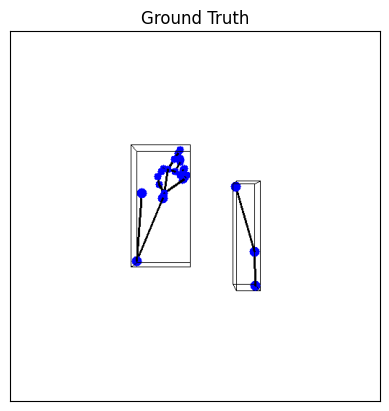

In [9]:
data_ = data.copy()
frame_idx = random.randint(0, data_.shape[0] - 1)
plot_hand_subplot(111, camera_params, data_[frame_idx, 0] * 1e3, data_[frame_idx, 1] * 1e3, 'Ground Truth')